# 02 — Qué maximiza el canal cruzado $H_2$

El canal cruzado del campo focal es
$H_2(q) = \int_0^a t_-(r)\,P(r)\,J_2(qr)\,r\,dr$, con $t_-=(t_p-t_s)/2$.
Su magnitud depende del **solapamiento** entre tres factores:

1. **El peso de Fresnel $t_-(r)$**: crece monótonamente hacia el borde de la
   pupila y su cociente con $t_+$ está acotado en incidencia rasante por
   $$ \frac{t_-}{t_+} \;\le\; \rho_{\max} = \frac{n_i-n_0}{n_i+n_0}. $$
   Un dioptrio de alto índice tiene más cruzada disponible que uno de vidrio.
2. **El núcleo $J_2(qr)$**: a las frecuencias características del lóbulo
   central ($qa \lesssim 3.8$), $J_2$ es creciente en casi toda la pupila
   (su primer máximo está en $qr \approx 3.05$, es decir en $r\approx 0.8a$
   para la frecuencia del primer cero). El canal cruzado se genera en la
   **zona externa** de la pupila, mientras $J_0$ pesa el centro.
3. **La amplitud de pupila $P(r)$**: concentrar el campo incidente donde
   $t_-\,J_2$ es grande (borde) maximiza la fracción cruzada
   $f_{\rm cross}$, a costa de transmisión.

Para un anillo infinitamente fino en el borde rasante vale el techo
$$ f_{\rm cross} \;\longrightarrow\; \frac{\rho_{\max}^2}{1+\rho_{\max}^2}, $$
cota asintótica para cualquier pupila sobre ese dioptrio.

Este cuaderno cuantifica cada factor y termina mostrando el efecto sobre el
patrón de intensidad (la conexión sistemática con la deformación del lóbulo
es el cuaderno 03).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

import spot_tools as st

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

base = dict(n0=1.0, z0=-10.0, zi=6.0, lam=532e-6)
NI_GLASS, NI_HIGH = 1.5, 2.4

for ni, name in [(NI_GLASS, "vidrio"), (NI_HIGH, "alto índice")]:
    rho_max = (ni - base["n0"]) / (ni + base["n0"])
    print(f"{name:12s} n_i={ni:g}:  ρ_max = {rho_max:.4f}   techo f_cross = {rho_max**2/(1+rho_max**2):.4f}")

vidrio       n_i=1.5:  ρ_max = 0.2000   techo f_cross = 0.0385
alto índice  n_i=2.4:  ρ_max = 0.4118   techo f_cross = 0.1450


## 1. El peso de Fresnel $t_-(r)$ y su cociente con $t_+$

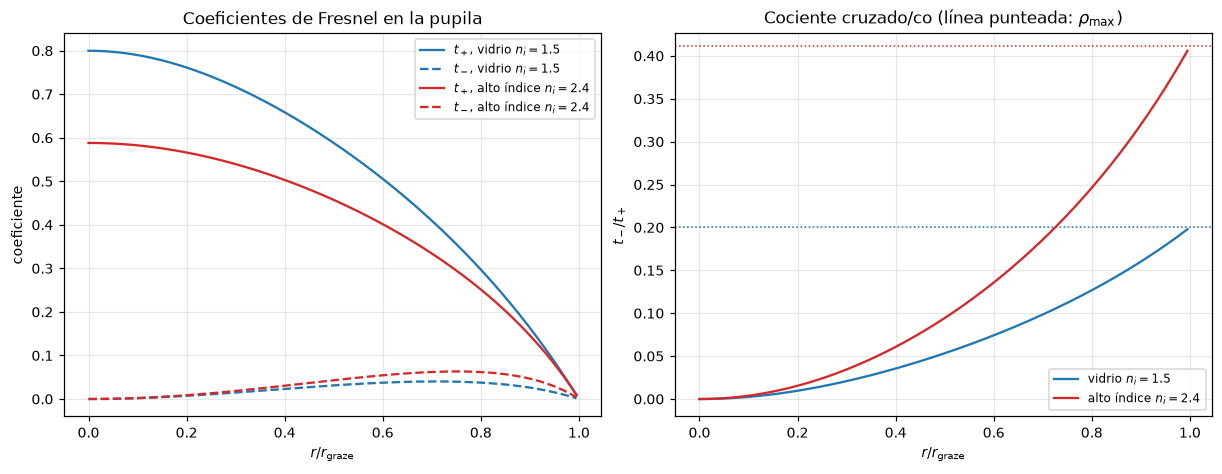

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ni, color, name in [(NI_GLASS, "C0", "vidrio $n_i=1.5$"), (NI_HIGH, "C3", "alto índice $n_i=2.4$")]:
    rg = st.grazing_radius(base["n0"], ni, base["z0"], base["zi"])
    r = np.linspace(0.0, 0.995 * rg, 1200)
    tp, ts = st.fresnel_coefficients(base["n0"], ni, base["z0"], base["zi"], r)
    t_plus, t_minus = 0.5 * (tp + ts), 0.5 * (tp - ts)
    rho_max = (ni - base["n0"]) / (ni + base["n0"])
    axes[0].plot(r / rg, t_plus, color=color, label=fr"$t_+$, {name}")
    axes[0].plot(r / rg, t_minus, color=color, ls="--", label=fr"$t_-$, {name}")
    axes[1].plot(r / rg, t_minus / t_plus, color=color, label=name)
    axes[1].axhline(rho_max, color=color, ls=":", lw=1)

axes[0].set(xlabel=r"$r/r_{\rm graze}$", ylabel="coeficiente", title="Coeficientes de Fresnel en la pupila")
axes[1].set(xlabel=r"$r/r_{\rm graze}$", ylabel=r"$t_-/t_+$",
            title=r"Cociente cruzado/co (línea punteada: $\rho_{\max}$)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.savefig(out_dir / "02_fresnel_weights.png", dpi=200)
plt.show()

$t_-$ es despreciable en el centro y crece hacia el borde; el cociente
$t_-/t_+$ alcanza $\rho_{\max}$ **solo en incidencia rasante**. Primer
ingrediente: apertura grande y borde de pupila cargado.

## 2. El solapamiento con $J_2(qr)$: dónde se genera la cruzada

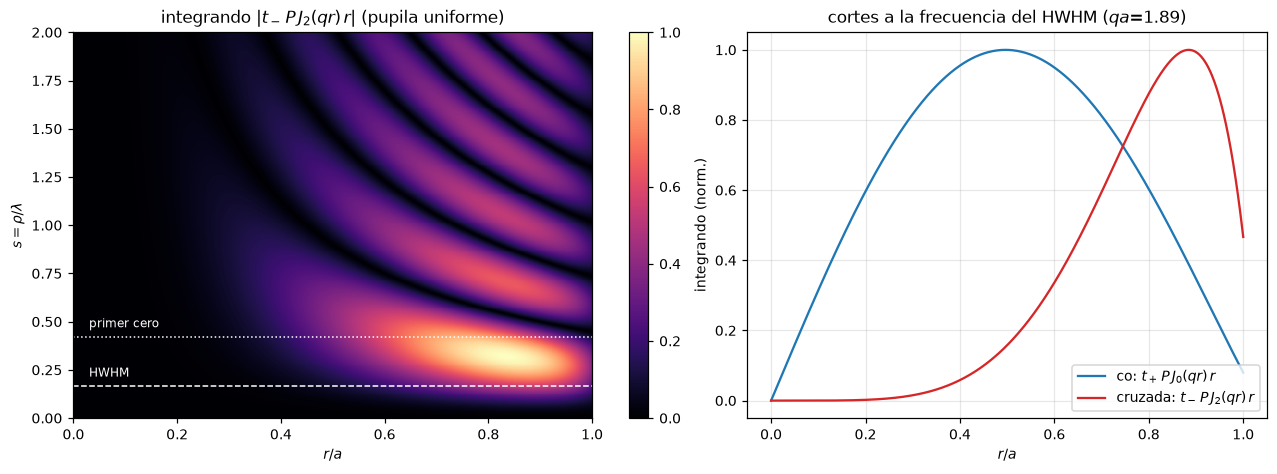

In [3]:
case_h = st.spot_case(ni=NI_HIGH, a_frac=0.97, **base)
r, s, a = case_h["r"], case_h["s"], case_h["a"]
t_minus = 0.5 * (case_h["tp"] - case_h["ts"])
t_plus = 0.5 * (case_h["tp"] + case_h["ts"])
m_h = st.spot_metrics(case_h)

# integrando de H2 en el plano (r/a, s)
W = np.abs(t_minus * case_h["P"] * jv(2, np.outer(case_h["q"], r)) * r)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
pcm = axes[0].pcolormesh(r / a, s, W / W.max(), cmap="magma", shading="auto")
axes[0].axhline(m_h["R_sca"], color="w", ls="--", lw=1)
axes[0].axhline(m_h["z_sca"], color="w", ls=":", lw=1)
axes[0].text(0.03, m_h["R_sca"] + 0.05, "HWHM", color="w", fontsize=8)
axes[0].text(0.03, m_h["z_sca"] + 0.05, "primer cero", color="w", fontsize=8)
axes[0].set(xlabel=r"$r/a$", ylabel=r"$s=\rho/\lambda$", ylim=(0, 2),
            title=r"integrando $|t_-\,P\,J_2(qr)\,r|$ (pupila uniforme)")
fig.colorbar(pcm, ax=axes[0], fraction=0.046)

# cortes a la frecuencia del HWHM: cruzada (J2) vs co (J0)
q_hwhm = m_h["R_sca"] / case_h["q_lambda"]
w2 = np.abs(t_minus * case_h["P"] * jv(2, q_hwhm * r) * r)
w0 = np.abs(t_plus * case_h["P"] * jv(0, q_hwhm * r) * r)
axes[1].plot(r / a, w0 / w0.max(), "C0", label=r"co: $t_+\,P\,J_0(qr)\,r$")
axes[1].plot(r / a, w2 / w2.max(), "C3", label=r"cruzada: $t_-\,P\,J_2(qr)\,r$")
axes[1].set(xlabel=r"$r/a$", ylabel="integrando (norm.)",
            title=f"cortes a la frecuencia del HWHM ($qa$={q_hwhm*a:.2f})")
axes[1].grid(alpha=0.3)
axes[1].legend()
fig.savefig(out_dir / "02_overlap_integrand.png", dpi=200)
plt.show()

A las frecuencias del lóbulo central el integrando cruzado está concentrado
en el **borde de la pupila** (producto de $t_-$ creciente y $J_2$ creciente),
mientras el canal co recibe contribuciones de toda la pupila. De aquí la
estrategia de maximización: **cargar el borde**.

## 3. Familia de borde $P=(r/a)^p$: fracción cruzada vs. transmisión

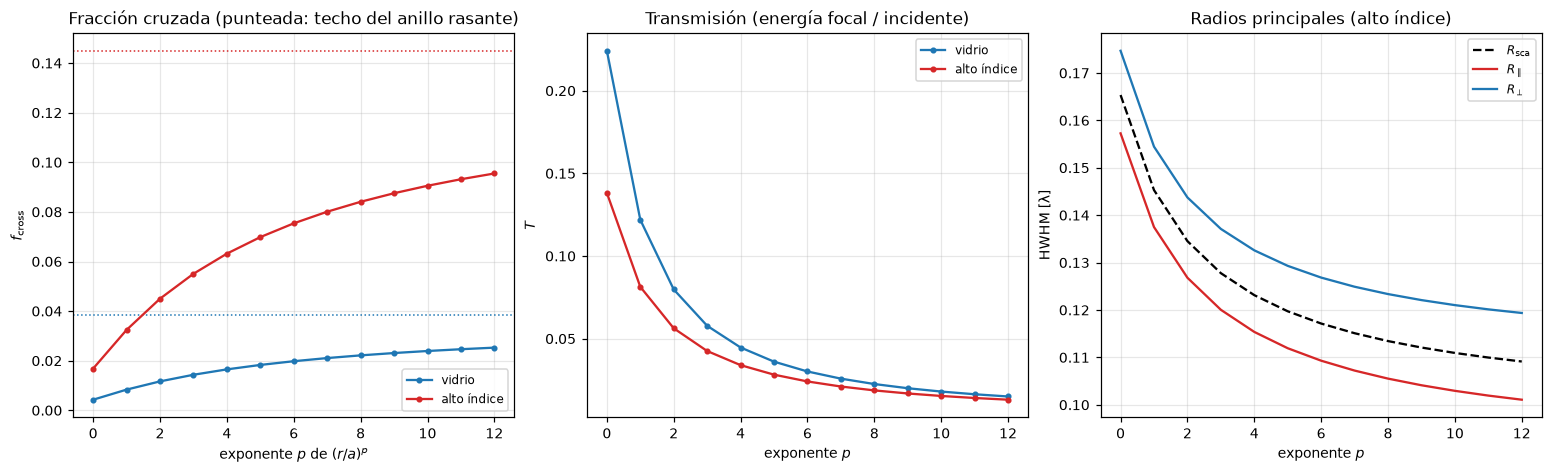

  p   f_cross       T    R_par   R_perp       e  (alto índice)
  0    0.0169   0.138   0.1573   0.1747  1.1108
  2    0.0450   0.056   0.1268   0.1438  1.1336
  4    0.0632   0.034   0.1154   0.1326  1.1491
  6    0.0754   0.024   0.1093   0.1268  1.1604
  8    0.0841   0.019   0.1055   0.1234  1.1690
 12    0.0955   0.013   0.1011   0.1194  1.1809


In [4]:
powers = np.arange(0, 13)
results = {}
for ni in (NI_GLASS, NI_HIGH):
    rows = []
    for p in powers:
        c = st.spot_case(ni=ni, a_frac=0.97, pupil=lambda rr, p=p: (rr / rr[-1]) ** p,
                         n_r=600, n_q=400, **base)
        rows.append((st.cross_fraction(c), st.transmission(c), st.spot_metrics(c)))
    results[ni] = rows

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ni, color, name in [(NI_GLASS, "C0", "vidrio"), (NI_HIGH, "C3", "alto índice")]:
    f = [row[0] for row in results[ni]]
    T = [row[1] for row in results[ni]]
    rho_max = (ni - base["n0"]) / (ni + base["n0"])
    axes[0].plot(powers, f, "o-", color=color, ms=3, label=name)
    axes[0].axhline(rho_max**2 / (1 + rho_max**2), color=color, ls=":", lw=1)
    axes[1].plot(powers, T, "o-", color=color, ms=3, label=name)

axes[0].set(xlabel=r"exponente $p$ de $(r/a)^p$", ylabel=r"$f_{\rm cross}$",
            title=r"Fracción cruzada (punteada: techo del anillo rasante)")
axes[1].set(xlabel=r"exponente $p$", ylabel=r"$T$", title="Transmisión (energía focal / incidente)")

mets = [row[2] for row in results[NI_HIGH]]
axes[2].plot(powers, [mm["R_sca"] for mm in mets], "k--", label=r"$R_{\rm sca}$")
axes[2].plot(powers, [mm["R_par"] for mm in mets], "C3", label=r"$R_\parallel$")
axes[2].plot(powers, [mm["R_perp"] for mm in mets], "C0", label=r"$R_\perp$")
axes[2].set(xlabel=r"exponente $p$", ylabel="HWHM [λ]", title="Radios principales (alto índice)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.savefig(out_dir / "02_edge_power_family.png", dpi=200)
plt.show()

print(f"{'p':>3s} {'f_cross':>9s} {'T':>7s} {'R_par':>8s} {'R_perp':>8s} {'e':>7s}  (alto índice)")
for p, (f, T, mm) in zip(powers, results[NI_HIGH]):
    if p in (0, 2, 4, 6, 8, 12):
        print(f"{p:3d} {f:9.4f} {T:7.3f} {mm['R_par']:8.4f} {mm['R_perp']:8.4f} {mm['ellipticity']:7.4f}")

El peso de borde sube $f_{\rm cross}$ hacia el techo (sin alcanzarlo) y
**paga con transmisión**. Nótese además que todos los radios bajan con $p$
(la pupila anular estrecha el lóbulo, tipo haz de Bessel) mientras la
elipticidad crece: la deformación relativa y el tamaño absoluto se mueven
a la vez — motivo para separarlos sistemáticamente en el cuaderno 03.

## 4. Pupilas anulares: posición y ancho del anillo

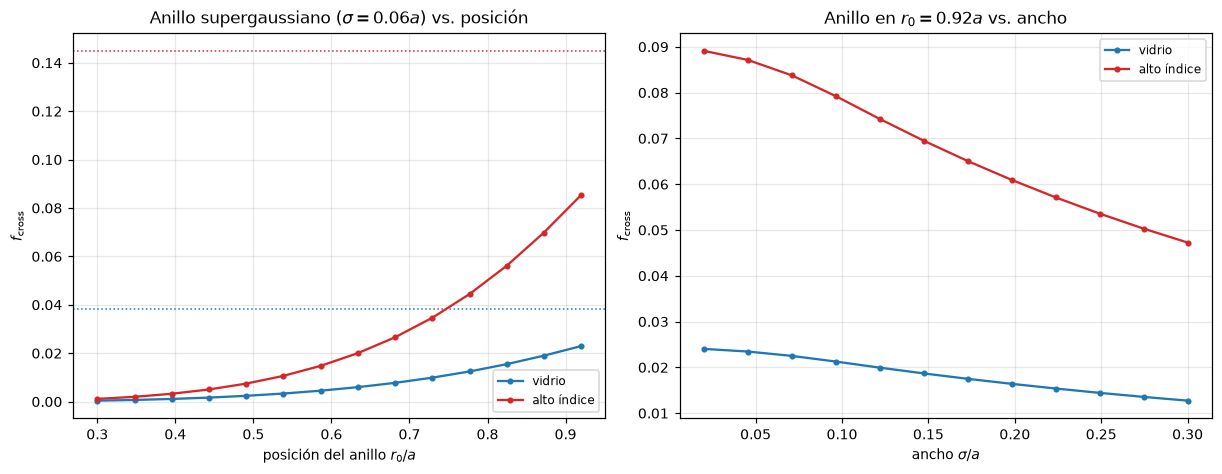

In [5]:
def ring_pupil(r0, sigma):
    return lambda rr: np.exp(-(((rr - r0) / sigma) ** 8))

case_tmp = st.spot_case(ni=NI_HIGH, a_frac=0.97, n_r=8, n_q=2, **base)
a_h = case_tmp["a"]
rg_glass = st.grazing_radius(base["n0"], NI_GLASS, base["z0"], base["zi"])
a_g = 0.97 * rg_glass

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

centers = np.linspace(0.3, 0.92, 14)
for ni, a_i, color, name in [(NI_GLASS, a_g, "C0", "vidrio"), (NI_HIGH, a_h, "C3", "alto índice")]:
    f_pos = [st.cross_fraction(st.spot_case(ni=ni, a_frac=0.97, pupil=ring_pupil(c0 * a_i, 0.06 * a_i),
                                            n_r=800, n_q=400, **base)) for c0 in centers]
    rho_max = (ni - base["n0"]) / (ni + base["n0"])
    axes[0].plot(centers, f_pos, "o-", color=color, ms=3, label=name)
    axes[0].axhline(rho_max**2 / (1 + rho_max**2), color=color, ls=":", lw=1)

widths = np.linspace(0.02, 0.30, 12)
for ni, a_i, color, name in [(NI_GLASS, a_g, "C0", "vidrio"), (NI_HIGH, a_h, "C3", "alto índice")]:
    f_w = [st.cross_fraction(st.spot_case(ni=ni, a_frac=0.97, pupil=ring_pupil(0.92 * a_i, w * a_i),
                                          n_r=800, n_q=400, **base)) for w in widths]
    axes[1].plot(widths, f_w, "o-", color=color, ms=3, label=name)

axes[0].set(xlabel=r"posición del anillo $r_0/a$", ylabel=r"$f_{\rm cross}$",
            title=r"Anillo supergaussiano ($\sigma=0.06a$) vs. posición")
axes[1].set(xlabel=r"ancho $\sigma/a$", ylabel=r"$f_{\rm cross}$",
            title=r"Anillo en $r_0=0.92a$ vs. ancho")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.savefig(out_dir / "02_ring_family.png", dpi=200)
plt.show()

La cruzada se maximiza con el anillo **lo más externo y angosto posible**
(limitado por el techo del dioptrio, no por la forma de la pupila): la
geometría de la pupila solo decide qué fracción del límite de Fresnel se
aprovecha.

## 5. Apertura e índice (pupila uniforme)

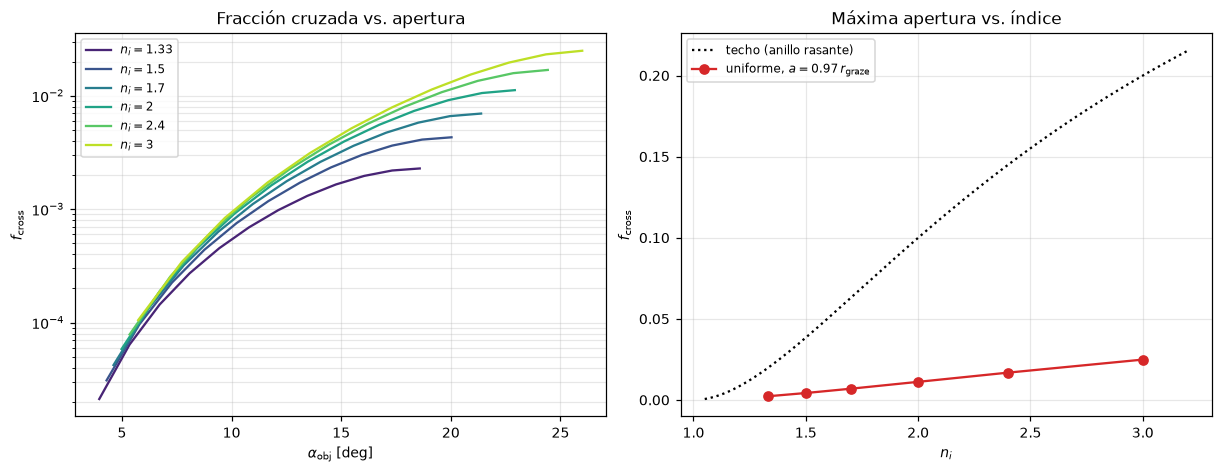

In [6]:
nis = [1.33, 1.5, 1.7, 2.0, 2.4, 3.0]
fracs = np.linspace(0.2, 0.97, 12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(nis)))
f_max_aperture = []
for ni, color in zip(nis, cmap):
    fs, alphas = [], []
    for fr in fracs:
        c = st.spot_case(ni=ni, a_frac=fr, n_r=600, n_q=400, **base)
        fs.append(st.cross_fraction(c))
        alphas.append(c["alpha_obj_deg"])
    axes[0].plot(alphas, fs, "-", color=color, label=fr"$n_i={ni:g}$")
    f_max_aperture.append(fs[-1])

axes[0].set(xlabel=r"$\alpha_{\rm obj}$ [deg]", ylabel=r"$f_{\rm cross}$", yscale="log",
            title="Fracción cruzada vs. apertura")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

ni_fine = np.linspace(1.05, 3.2, 200)
rho_fine = (ni_fine - base["n0"]) / (ni_fine + base["n0"])
axes[1].plot(ni_fine, rho_fine**2 / (1 + rho_fine**2), "k:", label="techo (anillo rasante)")
axes[1].plot(nis, f_max_aperture, "o-", color="C3", label=r"uniforme, $a=0.97\,r_{\rm graze}$")
axes[1].set(xlabel=r"$n_i$", ylabel=r"$f_{\rm cross}$", title="Máxima apertura vs. índice")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.savefig(out_dir / "02_aperture_index.png", dpi=200)
plt.show()

$f_{\rm cross}$ crece varios órdenes de magnitud con la apertura, y el
índice fija el techo alcanzable. Una pupila uniforme a máxima apertura
aprovecha solo una parte pequeña del techo (la mayor parte de su energía
entra por el centro, donde $t_-\approx 0$).

## 6. Las configuraciones que maximizan la cruzada, medidas

Cierre del cuaderno: las tres pupilas de la escalera de maximización
(uniforme → borde $(r/a)^6$ → anillo en $0.92a$), todas a alto índice y
apertura máxima, pasan por la **misma métrica de radios** del cuaderno 01.
La primera columna lleva anotados el contorno HWHM medido, el círculo
escalar de referencia y los radios principales; las otras muestran de dónde
sale la deformación ($\Delta I$) y el canal cruzado que la financia.

pupila             R∥ [λ]   R⊥ [λ]  R_sca [λ]       e  f_cross      T
uniforme           0.1573   0.1747     0.1654  1.1107   0.0169  0.138
borde $(r/a)^6$    0.1093   0.1268     0.1171  1.1604   0.0754  0.024
anillo $0.92a$     0.1009   0.1189     0.1089  1.1778   0.0823  0.027


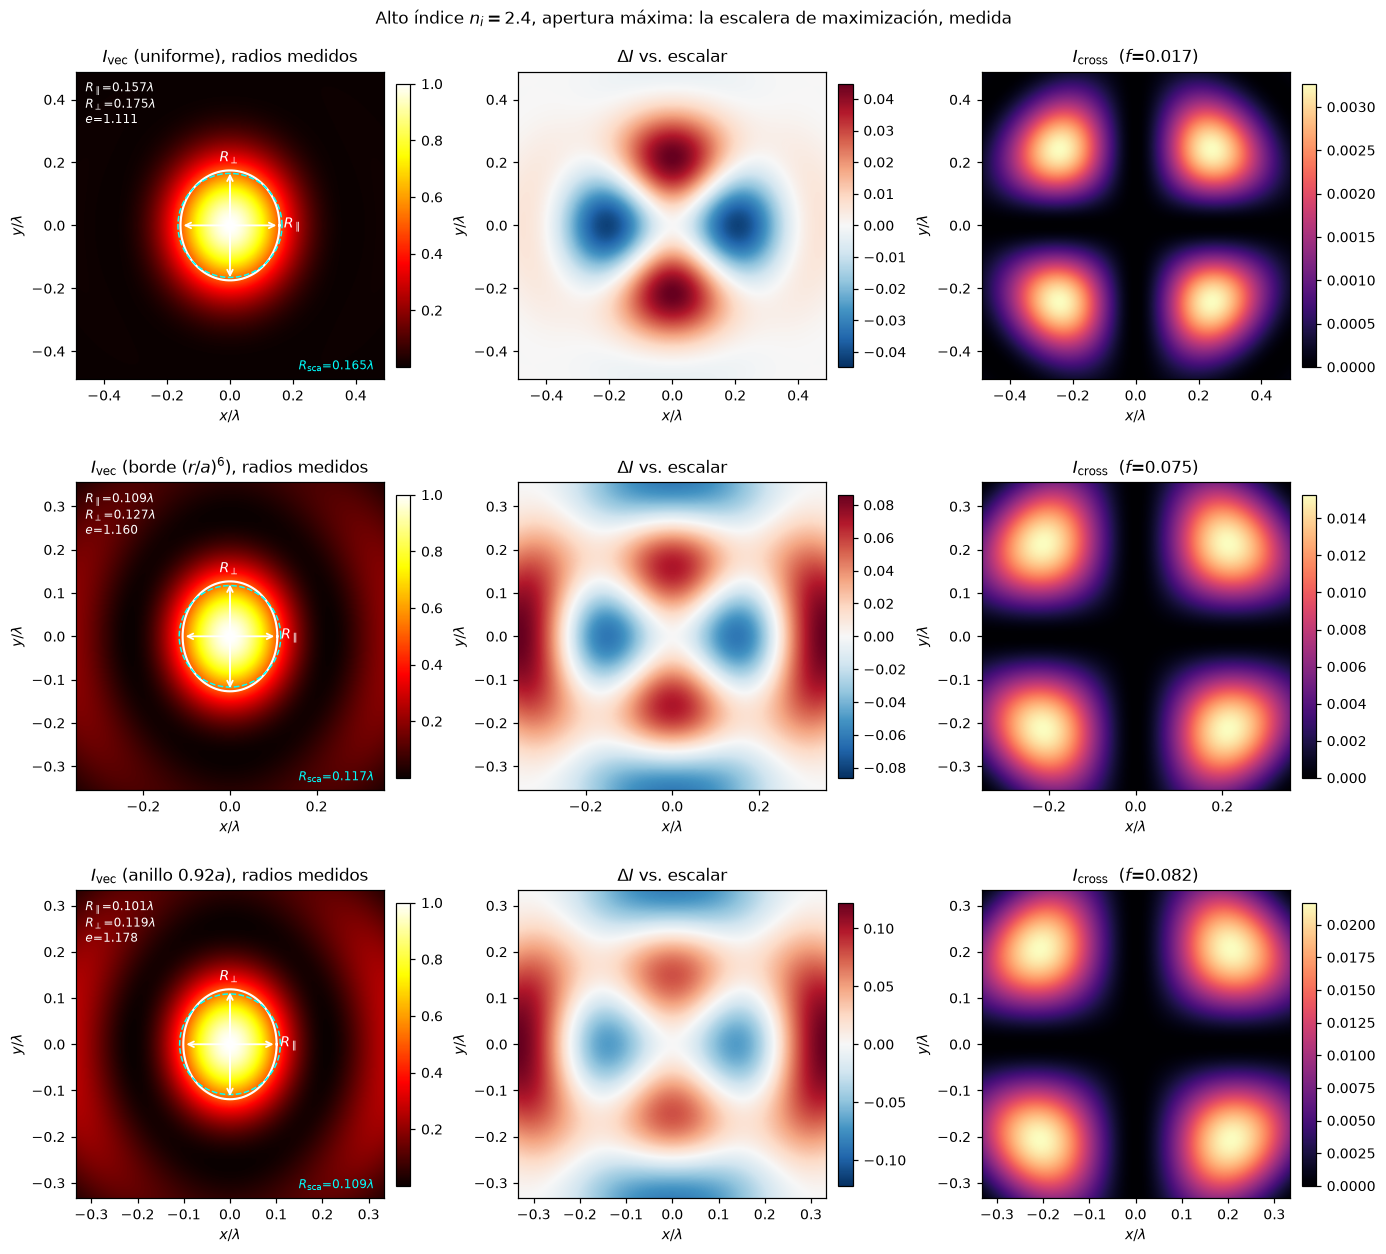

In [7]:
case_u = case_h
case_e = st.spot_case(ni=NI_HIGH, a_frac=0.97, pupil=lambda rr: (rr / rr[-1]) ** 6, **base)
case_r = st.spot_case(ni=NI_HIGH, a_frac=0.97,
                      pupil=lambda rr: np.exp(-(((rr - 0.92 * rr[-1]) / (0.08 * rr[-1])) ** 8)),
                      **base)

rows = [("uniforme", case_u), (r"borde $(r/a)^6$", case_e), (r"anillo $0.92a$", case_r)]
fig, axes = plt.subplots(3, 3, figsize=(12.5, 11.4), constrained_layout=True)
print(f"{'pupila':16s} {'R∥ [λ]':>8s} {'R⊥ [λ]':>8s} {'R_sca [λ]':>10s} "
      f"{'e':>7s} {'f_cross':>8s} {'T':>6s}")
for i, (name, cs) in enumerate(rows):
    half_size = st.display_half_size(cs)
    im0, mm = st.plot_spot_with_radii(axes[i, 0], cs, half_size=half_size, n_img=350)
    axes[i, 0].set_title(rf"$I_{{\rm vec}}$ ({name}), radios medidos")
    fig.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    maps = st.intensity_maps(cs, half_size, n_img=350, alpha=0.0)
    I0 = maps["I_sca"].max()
    panels = [
        ((maps["I_vec"] - maps["I_sca"]) / I0, "RdBu_r", "sym", r"$\Delta I$ vs. escalar"),
        (maps["I_cross"] / I0, "magma", None, rf"$I_{{\rm cross}}$  ($f$={st.cross_fraction(cs):.3f})"),
    ]
    for j, (img, cmap_j, mode, title) in enumerate(panels, start=1):
        vmax = np.abs(img).max()
        kw = dict(vmin=-vmax, vmax=vmax) if mode == "sym" else dict(vmin=0, vmax=vmax)
        im = axes[i, j].imshow(img, extent=maps["extent"], origin="lower", cmap=cmap_j, **kw)
        axes[i, j].set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
        fig.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
    print(f"{name:16s} {mm['R_par']:8.4f} {mm['R_perp']:8.4f} {mm['R_sca']:10.4f} "
          f"{mm['ellipticity']:7.4f} {st.cross_fraction(cs):8.4f} {st.transmission(cs):6.3f}")
fig.suptitle("Alto índice $n_i=2.4$, apertura máxima: la escalera de maximización, medida", fontsize=11)
fig.savefig(out_dir / "02_pattern_effect.png", dpi=200)
plt.show()

## Conclusiones

1. El canal cruzado se genera en la **zona externa de la pupila**: allí
   coinciden el máximo de $t_-(r)$ (rasante) y el crecimiento de $J_2(qr)$ a
   las frecuencias del lóbulo central — tal como sugiere el argumento de
   solapamiento.
2. La jerarquía de palancas sobre $f_{\rm cross}$: **apertura** (órdenes de
   magnitud), **índice** (fija el techo $\rho_{\max}^2/(1+\rho_{\max}^2)$) y
   **forma de pupila** (decide qué fracción del techo se aprovecha, pagando
   transmisión).
3. Con peso de borde el lóbulo se **encoge globalmente** (efecto anular tipo
   Bessel) a la vez que se hace más **elíptico** (efecto vectorial):
   tamaño y deformación deben separarse — ese es el objeto del cuaderno 03.